In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from gensim.models import Word2Vec
from node2vec import Node2Vec
from sklearn.manifold import TSNE
import networkx as nx
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
proc_dir = Path("../data/processed")
model_dir = Path("../models/embeddings")
model_dir.mkdir(parents=True, exist_ok=True)

In [3]:
df = pd.read_csv(proc_dir / "reddit_adr_clean.csv")
G = nx.read_gml(proc_dir / "adr_network.gml")

## Word2Vec

In [4]:
corpus = df.groupby("post_id")["adr"].apply(list).tolist()
w2v_model = Word2Vec(
    sentences=corpus, vector_size=64, window=3,
    min_count=2, sg=1, workers=4, epochs=100
)
w2v_model.save(str(model_dir / "w2v_adr.model"))
print("Saved Word2Vec model.")

Saved Word2Vec model.


## Node2Vec

In [5]:
node2vec = Node2Vec(G, dimensions=64, walk_length=10, num_walks=50, workers=1, seed=42)
node2vec_model = node2vec.fit(window=5, min_count=1, batch_words=4)
node2vec_model.save(str(model_dir / "node2vec_adr.model"))
print("Saved Node2Vec model.")

Computing transition probabilities:   0%|          | 0/58 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 50/50 [00:00<00:00, 503.16it/s]


Saved Node2Vec model.


## Preparing embeddings for visualization

In [6]:
adr_terms = list(node2vec_model.wv.index_to_key)
adr_vecs = np.array([node2vec_model.wv[w] for w in adr_terms])
tsne = TSNE(n_components=2, random_state=42, perplexity=20)
adr_2d = tsne.fit_transform(adr_vecs)

emb_df = pd.DataFrame({
    "adr": adr_terms,
    "x": adr_2d[:,0],
    "y": adr_2d[:,1]
})
emb_df.to_csv(proc_dir / "adr_embeddings.csv", index=False)

## Static visualization

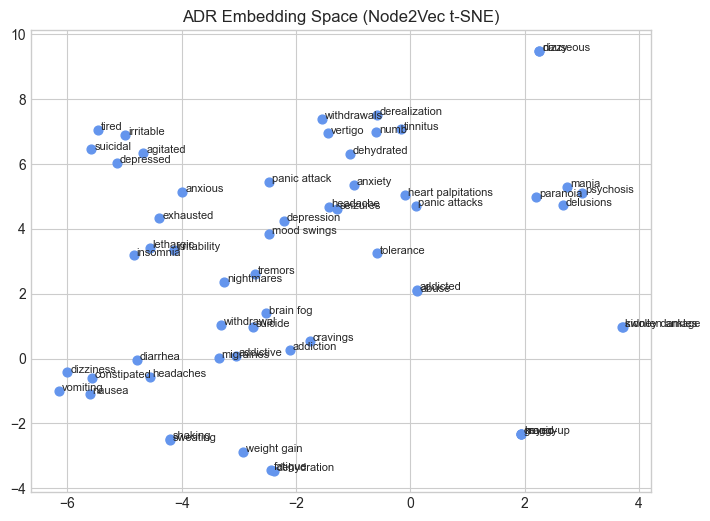

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(emb_df["x"], emb_df["y"], s=40, color="cornflowerblue")
for _, r in emb_df.iterrows():
    plt.text(r.x+0.05, r.y, r.adr, fontsize=8)
plt.title("ADR Embedding Space (Node2Vec t-SNE)")
plt.savefig(proc_dir / "fig_embeddings_tsne.png", dpi=300)

## Similarity check word2vec & node2vec

In [9]:
target = "depression"

if target in node2vec_model.wv:
    print(f"\n[Node2Vec] Most similar to '{target}':")
    print(node2vec_model.wv.most_similar(target, topn=5))

if target in w2v_model.wv:
    print(f"\n[Word2Vec] Most similar to '{target}':")
    print(w2v_model.wv.most_similar(target, topn=5))


[Node2Vec] Most similar to 'depression':
[('mood swings', 0.9744047522544861), ('seizures', 0.9406392574310303), ('headache', 0.9360507726669312), ('anxiety', 0.9176808595657349), ('anxious', 0.8821637630462646)]

[Word2Vec] Most similar to 'depression':
[('anxiety', 0.9941468834877014), ('insomnia', 0.9940425157546997), ('withdrawal', 0.9936332106590271), ('shaking', 0.9924118518829346), ('numb', 0.992276668548584)]
